# 1. 심층신경망

## 1.1 MNIST 데이터를 이용한 기초 케라스 예제



MNIST (Modified National Institute of Standards and Technology) 데이터는 사람들이 직접 손으로 쓴 0부터 9까지의 숫자를 이미지화한 데이터이다. 맨 처음에 코딩을 배울 때 "Hello World!"를 출력하듯이, 딥러닝을 배울 때 MNIST 데이터를 사용한다!

X_train shape : (60000, 28, 28)
y_train shape : (60000,)
X_test shape : (10000, 28, 28)
y_test shape : (10000,)


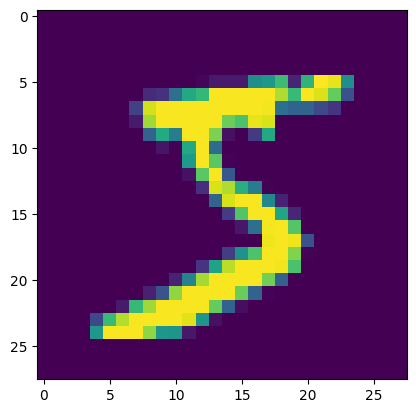

Label:  5


In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
mnist = tf.keras.datasets.mnist.load_data()
(X_train, y_train), (X_test, y_test) = mnist
print(f"X_train shape : {X_train.shape}")
print(f"y_train shape : {y_train.shape}")
print(f"X_test shape : {X_test.shape}")
print(f"y_test shape : {y_test.shape}")
plt.imshow(X_train[0])
plt.show()
print('Label: ', y_train[0])

MNIST 데이터는 6만 개의 학습 데이터와 1만 개의 검증 데이터로 구성되어 있다. 각 이미지는 $28\times28$ 픽셀이며, 각각의 픽셀은 0(흰색)부터 255(검은색)까지의 값을 가진다. 또한 각 이미지별로 어떤 숫자인지 분류되어 있다.

In [ ]:
print(X_train[0][5][15])
X_train, X_test = X_train / 255.0, X_test / 255.0
print(X_train[0][5][15])

18
0.07058823529411765


먼저 각 픽셀의 값들이 0 ~ 1 사이의 값을 가지도록 255로 나누어주어야 한다. 이를 정규화(Normalization)라고 하는데, 입력 데이터의 전처리는 학습속도와 안정적인 학습에 중요하다.

In [ ]:
tf.random.set_seed(42)

model = tf.keras.Sequential()

model.add(tf.keras.layers.Input(shape=[28, 28]))
model.add(tf.keras.layers.Flatten())

model.add(tf.keras.layers.Dense(100, activation="sigmoid"))
model.add(tf.keras.layers.Dense(100, activation="sigmoid"))

model.add(tf.keras.layers.Dense(10, activation="softmax"))

1. 먼저 결과를 재현할 수 있도록 랜덤 시드를 설정해야 한다.
https://www.tensorflow.org/api_docs/python/tf/random/set_seed

2. Sequential 모델은 가장 간단한 신경망 모델로, 층을 일렬로 순서대로 쌓아서 구성한다.

3. 첫 번째 층은 입력 층으로, (배치 크기는 포함하지 않은) 샘플의 크기를 나타내는 shape를 매개변수로 받는다. flatten 층은 입력값이 $28\times28$인 행렬을 $1\times784$인 벡터로 바꾸어 준다.

4. 뉴런 100개를 가진 Dense 층 2개를 추가한다. Dense층은 입력 뉴런과 출력 뉴런이 모두 연결되어 있는 것을 말한다. 여기서 Dense 층들은 Sigmoid 함수를 활성화 함수로 사용한다.

5. 마지막으로 뉴런 10개를 가지는 Dense 출력 층을 추가한다. 10개의 숫자를 분류하는게 목적이므로 softmax 함수를 활성화 함수로 사용해야 한다.
마지막 뉴런 10개에서 나온 값을 $z_{0},\cdots,z_{9}$라고 한다면, softmax 함수는 다음과 같이 정의된다.
<br>
<center>$p_{i}=\frac{e^{z_{i}}}{\sum_{j=1}^{10}e^{z_{j}}}$</center>
<br>
따라서 softmax 함수는 0 ~ 9의 숫자가 될 확률을 나타낸다.

In [ ]:
model.summary()

Model: "sequential_13"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_13 (Flatten)        (None, 784)               0         
                                                                 
 dense_43 (Dense)            (None, 100)               78500     
                                                                 
 dense_44 (Dense)            (None, 100)               10100     
                                                                 
 dense_45 (Dense)            (None, 10)                1010      
                                                                 
Total params: 89610 (350.04 KB)
Trainable params: 89610 (350.04 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer="sgd",
              metrics=["accuracy"])

1. 먼저 손실함수는 우리가 구성한 신경망이 예측한 값과 실제 값의 차이를 측정하는 함수로, 한마디로 "오차"라고 할 수 있다. 당연하지만, 오차를 줄이는 방향으로 가중치를 조정해야 한다.
여기서는 다중 클래스 분류에 사용되는 categorical_crossentropy를 사용해야 한다. 현재 출력값이 원-핫 벡터 형태가 아니라 정수 형태이기 때문에 sparse_categorical_crossentropy를 사용해야 한다.

2. optimizer는 손실함수를 줄이는 방법이다. 여기서는 가장 기본적인 stochastic gradient descent를 사용하였다.

3. metrics는 모델을 평가하기 위해 사용하는 지표로, 여기서는 정확도를 사용하고 있다.

In [ ]:
history = model.fit(X_train, y_train, epochs=30, validation_split=0.2)

Epoch 1/30
1500/1500 [==============================] - 5s 3ms/step - loss: 2.2349 - accuracy: 0.2848 - val_loss: 2.1371 - val_accuracy: 0.3934
Epoch 2/30
1500/1500 [==============================] - 6s 4ms/step - loss: 1.9374 - accuracy: 0.5766 - val_loss: 1.6610 - val_accuracy: 0.6718
Epoch 3/30
1500/1500 [==============================] - 4s 3ms/step - loss: 1.3857 - accuracy: 0.6879 - val_loss: 1.1242 - val_accuracy: 0.7484
Epoch 4/30
1500/1500 [==============================] - 4s 3ms/step - loss: 0.9819 - accuracy: 0.7656 - val_loss: 0.8229 - val_accuracy: 0.8147
Epoch 5/30
1500/1500 [==============================] - 6s 4ms/step - loss: 0.7591 - accuracy: 0.8103 - val_loss: 0.6560 - val_accuracy: 0.8422
Epoch 6/30
1500/1500 [==============================] - 4s 3ms/step - loss: 0.6305 - accuracy: 0.8379 - val_loss: 0.5564 - val_accuracy: 0.8627
Epoch 7/30
1500/1500 [==============================] - 4s 3ms/step - loss: 0.5498 - accuracy: 0.8564 - val_loss: 0.4931 - val_accuracy:

이제 모델 구성이 완료되었으니 학습을 시작하면 된다!
<br>
<br>
먼저 epoch는 전체 데이터(60000개)를 학습하는 횟수를 의미한다. epoch 값이 너무 작을 경우 학습이 부족해 예측을 제대로 못하는 underfitting이, 반대로 epoch 값이 너무 클 경우 outlier를 잘 예측하지 못하고 학습 데이터만 잘 맞추게 되는 overfitting이 발생하게 된다.
<br>
<br>
batch size는 가중치를 한 번 업데이트 할 때 사용되는 데이터의 숫자를 의미한다. batch size는 2의 배수(2, 4, 8, 16, $\cdots$)로 사용하며, keras의 기본적인 batch size는 32이다.
<br>
<br>
데이터는 크게 training, validation, test로 나누어진다.
training set은 오로지 학습에만 사용되는 데이터로 training set을 이용해 hyperparameter와 weight 등을 조절할 때 직접적으로 사용된다.
<br>
validation set과 test set은 평가에 사용되는 데이터이다. 차이점이 있다면 validation set을 이용하여 학습을 어느 정도로 할지 정한다는 것이다.

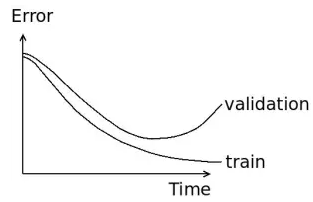
<br>
예를 들어, epoch가 증가할수록 training set의 오차는 감소할 것이고, 반대로 validation set의 오차는 처음에는 감소하다가 나중에는 training set에 overfitting 되어서 증가할 것이다. 따라서 validation set을 이용하여 적절한 epoch를 파악하는데 사용할 수 있다.
<br>
<br>
여기서는 20%의 데이터를 validation set으로 사용하였다. 따라서 1 에포크 동안 $60000\times0.8=48000$개를 training set으로 12000개를 validation set으로 사용하며, 가중치는 $48000/32=1500$번 업데이트 하게 된다.

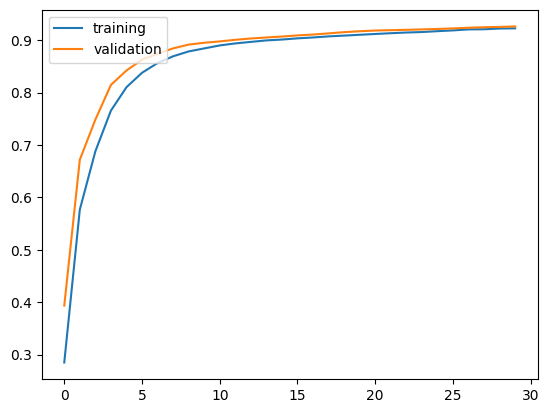

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['training', 'validation'], loc = 'upper left')
plt.show()

In [ ]:
model.evaluate(X_test, y_test)

313/313 [==============================] - 1s 2ms/step - loss: 0.2576 - accuracy: 0.9263


[0.25759270787239075, 0.9262999892234802]

# 1.2 가중치 초기화 (Weight Initialization)

초기 가중치를 잘 설정해 주지 않으면 가중치를 업데이트하는 역전파 과정에서 기울기가 소실되거나 (주로 RNN에서) 폭주되는 현상이 발생하기도 한다.

가중치 초기화 방법에는 LeCun 초기화, Xavier 초기화, He 초기화 등 다양한 방법이 있다. keras는 기본적으로 균등 분포의 Glorot 초기화를 사용한다. 가장 최신의 초기화 방식은 He 초기화이다.

In [ ]:
model.add(tf.keras.layers.Dense(100, activation="sigmoid", kernel_initializer="he_normal"))

Epoch 1/30
1500/1500 [==============================] - 6s 4ms/step - loss: 2.1809 - accuracy: 0.3671 - val_loss: 1.9936 - val_accuracy: 0.5399
Epoch 2/30
1500/1500 [==============================] - 7s 5ms/step - loss: 1.6825 - accuracy: 0.6615 - val_loss: 1.3270 - val_accuracy: 0.7291
Epoch 3/30
1500/1500 [==============================] - 4s 3ms/step - loss: 1.0975 - accuracy: 0.7656 - val_loss: 0.8806 - val_accuracy: 0.8139
Epoch 4/30
1500/1500 [==============================] - 4s 3ms/step - loss: 0.7937 - accuracy: 0.8181 - val_loss: 0.6738 - val_accuracy: 0.8467
Epoch 5/30
1500/1500 [==============================] - 6s 4ms/step - loss: 0.6413 - accuracy: 0.8442 - val_loss: 0.5615 - val_accuracy: 0.8633
Epoch 6/30
1500/1500 [==============================] - 4s 3ms/step - loss: 0.5522 - accuracy: 0.8599 - val_loss: 0.4922 - val_accuracy: 0.8752
Epoch 7/30
1500/1500 [==============================] - 4s 3ms/step - loss: 0.4944 - accuracy: 0.8706 - val_loss: 0.4466 - val_accuracy:

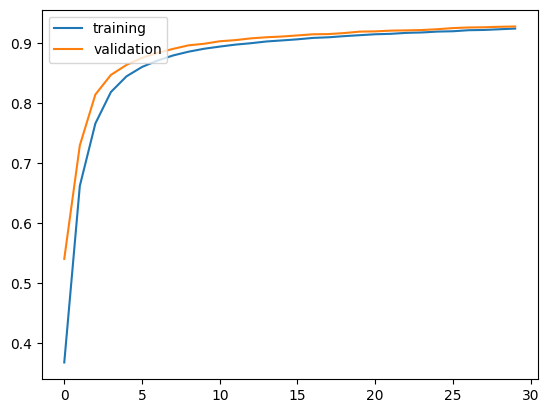

In [ ]:
mnist = tf.keras.datasets.mnist.load_data()
(X_train, y_train), (X_test, y_test) = mnist
X_train, X_test = X_train / 255.0, X_test / 255.0
tf.random.set_seed(42)
model = tf.keras.Sequential()
model.add(tf.keras.layers.Input(shape=[28, 28]))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(100, activation="sigmoid", kernel_initializer="he_normal"))
model.add(tf.keras.layers.Dense(100, activation="sigmoid", kernel_initializer="he_normal"))
model.add(tf.keras.layers.Dense(10, activation="softmax"))
model.compile(loss="sparse_categorical_crossentropy",
              optimizer="sgd",
              metrics=["accuracy"])
history = model.fit(X_train, y_train, epochs=30, validation_split=0.2)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['training', 'validation'], loc = 'upper left')
plt.show()

In [ ]:
model.evaluate(X_test, y_test)

313/313 [==============================] - 1s 2ms/step - loss: 0.2526 - accuracy: 0.9267


[0.2525874376296997, 0.9266999959945679]

# 1.3 활성화 함수

초기에는 생물학적 뉴런의 방식과 비슷한 sigmoid 함수가 최선의 선택이라고 생각했다. 하지만 기울기 소실 같은 문제가 자주 발생하였다. 2013년 AlexNet과 함께 혜성처럼 등장한 ReLU는 기울기 소실 문제를 거의 해결해주기 때문에 은닉층에서 널리 사용되는 함수이다.

Epoch 1/30
1500/1500 [==============================] - 6s 4ms/step - loss: 0.6638 - accuracy: 0.8211 - val_loss: 0.3185 - val_accuracy: 0.9082
Epoch 2/30
1500/1500 [==============================] - 5s 3ms/step - loss: 0.3041 - accuracy: 0.9126 - val_loss: 0.2555 - val_accuracy: 0.9263
Epoch 3/30
1500/1500 [==============================] - 6s 4ms/step - loss: 0.2525 - accuracy: 0.9281 - val_loss: 0.2239 - val_accuracy: 0.9358
Epoch 4/30
1500/1500 [==============================] - 4s 3ms/step - loss: 0.2195 - accuracy: 0.9371 - val_loss: 0.2026 - val_accuracy: 0.9429
Epoch 5/30
1500/1500 [==============================] - 4s 3ms/step - loss: 0.1952 - accuracy: 0.9441 - val_loss: 0.1863 - val_accuracy: 0.9486
Epoch 6/30
1500/1500 [==============================] - 6s 4ms/step - loss: 0.1762 - accuracy: 0.9496 - val_loss: 0.1695 - val_accuracy: 0.9532
Epoch 7/30
1500/1500 [==============================] - 5s 3ms/step - loss: 0.1597 - accuracy: 0.9542 - val_loss: 0.1599 - val_accuracy:

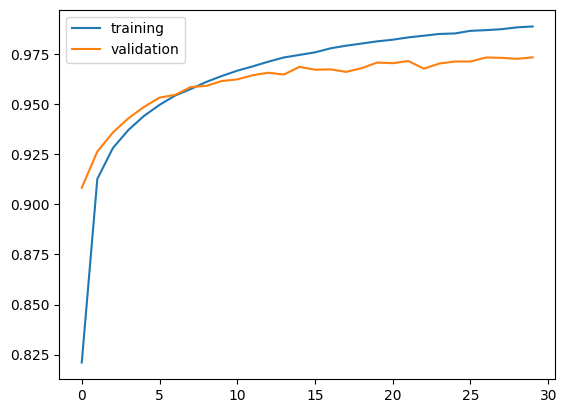

In [ ]:
mnist = tf.keras.datasets.mnist.load_data()
(X_train, y_train), (X_test, y_test) = mnist
X_train, X_test = X_train / 255.0, X_test / 255.0
tf.random.set_seed(42)
model = tf.keras.Sequential()
model.add(tf.keras.layers.Input(shape=[28, 28]))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(100, activation="relu", kernel_initializer="he_normal"))
model.add(tf.keras.layers.Dense(100, activation="relu", kernel_initializer="he_normal"))
model.add(tf.keras.layers.Dense(10, activation="softmax"))
model.compile(loss="sparse_categorical_crossentropy",
              optimizer="sgd",
              metrics=["accuracy"])
history = model.fit(X_train, y_train, epochs=30, validation_split=0.2)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['training', 'validation'], loc = 'upper left')
plt.show()

In [ ]:
model.evaluate(X_test, y_test)

313/313 [==============================] - 1s 2ms/step - loss: 0.0872 - accuracy: 0.9740


[0.08724375814199448, 0.9739999771118164]

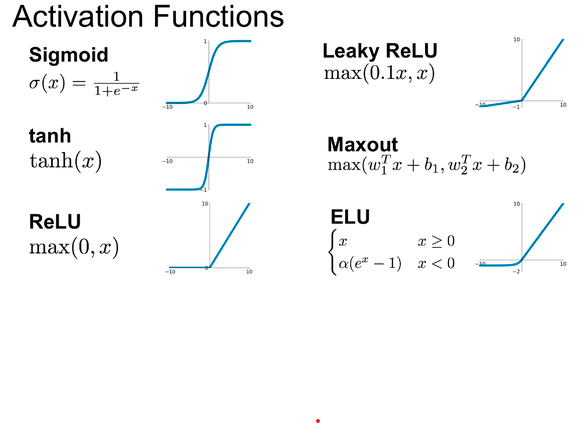

# 1.4 Batch Normalization

ReLU와 He 초기화를 함께 사용하면 학습 초기에 기울기 소실이나 폭주 문제를 크게 줄일 수 있지만, 훈련하는 동안 다시 발생할 수도 있다.
<br>
Batch Normalization은 입력값을 정규화 시켜준다. Batch Normalization은 성능을 크게 향상시켜주며, 가중치 초기화에 신경망이 덜 민감해져서 훨씬 큰 학습률을 사용할 수 있다. 특히나 Batch Normalization은 regularization 역할을 하여 overfitting을 방지해 준다.

Epoch 1/30
1500/1500 [==============================] - 11s 6ms/step - loss: 0.4639 - accuracy: 0.8613 - val_loss: 0.2459 - val_accuracy: 0.9263
Epoch 2/30
1500/1500 [==============================] - 8s 6ms/step - loss: 0.2442 - accuracy: 0.9268 - val_loss: 0.1892 - val_accuracy: 0.9450
Epoch 3/30
1500/1500 [==============================] - 6s 4ms/step - loss: 0.1937 - accuracy: 0.9431 - val_loss: 0.1667 - val_accuracy: 0.9506
Epoch 4/30
1500/1500 [==============================] - 6s 4ms/step - loss: 0.1670 - accuracy: 0.9500 - val_loss: 0.1520 - val_accuracy: 0.9550
Epoch 5/30
1500/1500 [==============================] - 5s 4ms/step - loss: 0.1403 - accuracy: 0.9585 - val_loss: 0.1416 - val_accuracy: 0.9578
Epoch 6/30
1500/1500 [==============================] - 7s 5ms/step - loss: 0.1264 - accuracy: 0.9627 - val_loss: 0.1337 - val_accuracy: 0.9604
Epoch 7/30
1500/1500 [==============================] - 5s 4ms/step - loss: 0.1120 - accuracy: 0.9665 - val_loss: 0.1268 - val_accuracy

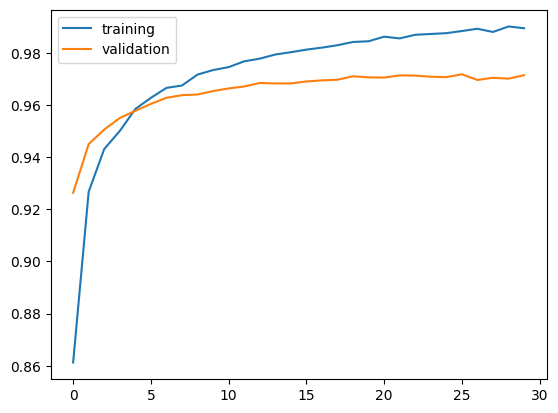

In [ ]:
mnist = tf.keras.datasets.mnist.load_data()
(X_train, y_train), (X_test, y_test) = mnist
X_train, X_test = X_train / 255.0, X_test / 255.0
tf.random.set_seed(42)
model = tf.keras.Sequential()
model.add(tf.keras.layers.Input(shape=[28, 28]))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(100, activation="relu", kernel_initializer="he_normal"))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(100, activation="relu", kernel_initializer="he_normal"))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(10, activation="softmax"))
model.compile(loss="sparse_categorical_crossentropy",
              optimizer="sgd",
              metrics=["accuracy"])
history = model.fit(X_train, y_train, epochs=30, validation_split=0.2)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['training', 'validation'], loc = 'upper left')
plt.show()

In [ ]:
model.evaluate(X_test, y_test)

313/313 [==============================] - 2s 5ms/step - loss: 0.1242 - accuracy: 0.9688


[0.12422309815883636, 0.9688000082969666]

# 1.5 출력층과 손실 함수

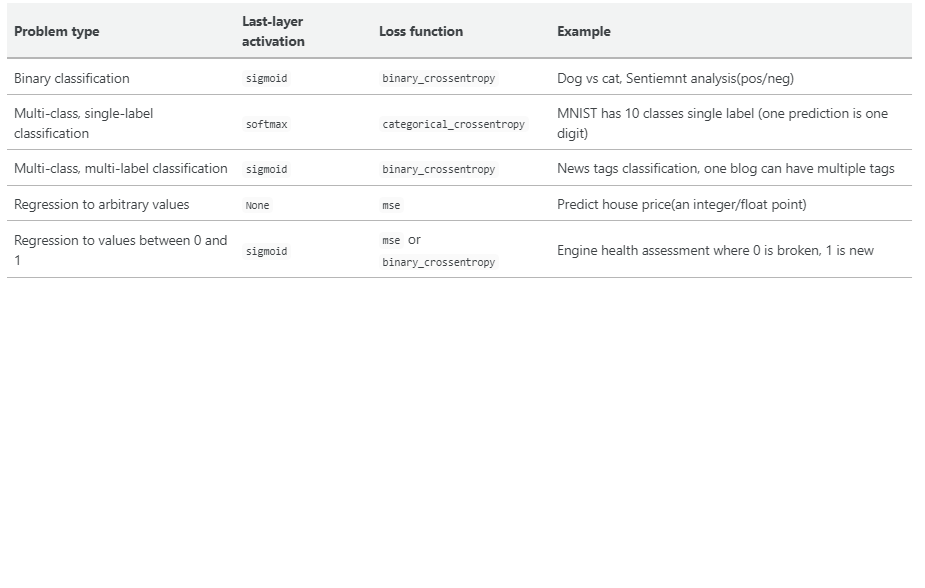

# 1.6 Optimizer

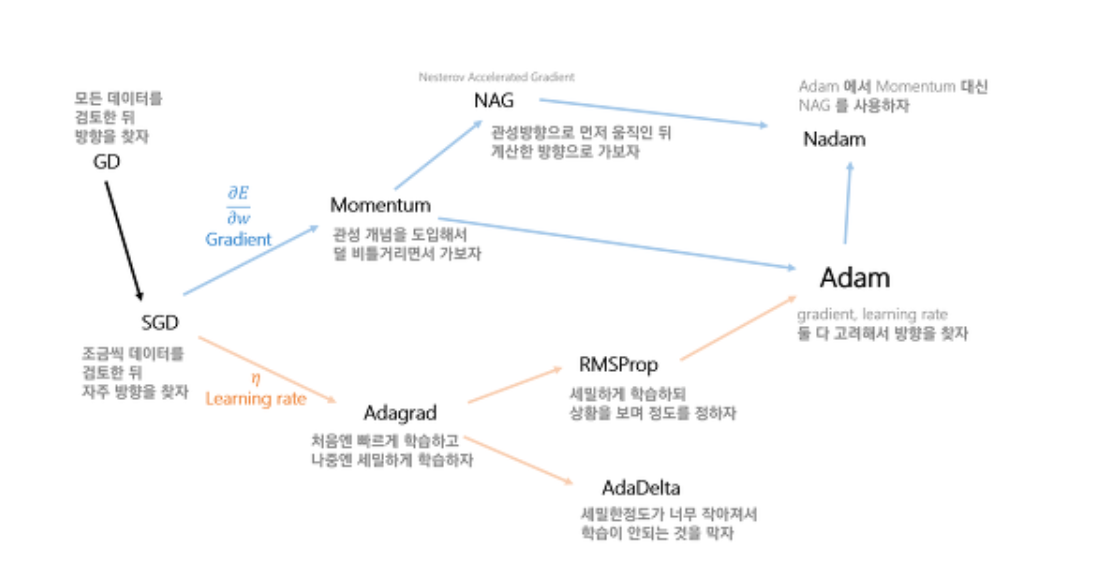

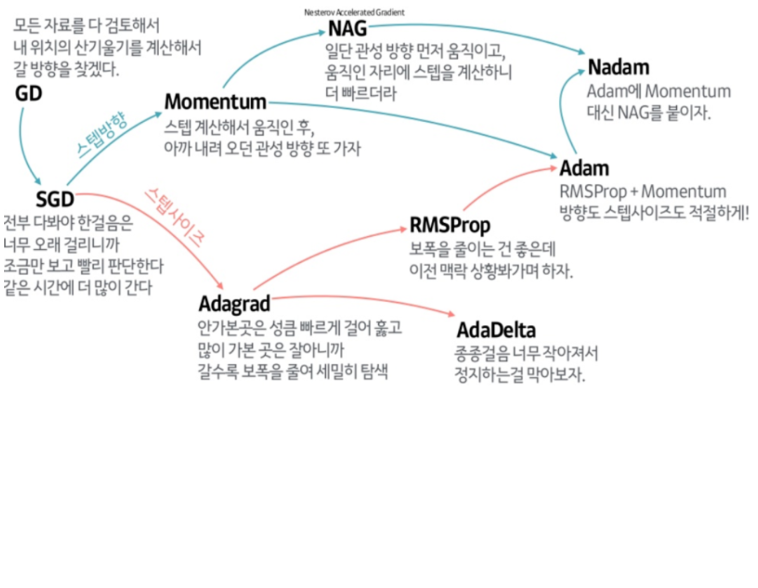

Epoch 1/30
1500/1500 [==============================] - 11s 6ms/step - loss: 0.2802 - accuracy: 0.9141 - val_loss: 0.1324 - val_accuracy: 0.9601
Epoch 2/30
1500/1500 [==============================] - 7s 5ms/step - loss: 0.1351 - accuracy: 0.9578 - val_loss: 0.1106 - val_accuracy: 0.9674
Epoch 3/30
1500/1500 [==============================] - 10s 7ms/step - loss: 0.1001 - accuracy: 0.9691 - val_loss: 0.1094 - val_accuracy: 0.9676
Epoch 4/30
1500/1500 [==============================] - 9s 6ms/step - loss: 0.0881 - accuracy: 0.9713 - val_loss: 0.0984 - val_accuracy: 0.9724
Epoch 5/30
1500/1500 [==============================] - 8s 5ms/step - loss: 0.0699 - accuracy: 0.9775 - val_loss: 0.0940 - val_accuracy: 0.9736
Epoch 6/30
1500/1500 [==============================] - 10s 7ms/step - loss: 0.0629 - accuracy: 0.9796 - val_loss: 0.0935 - val_accuracy: 0.9744
Epoch 7/30
1500/1500 [==============================] - 8s 5ms/step - loss: 0.0527 - accuracy: 0.9828 - val_loss: 0.1090 - val_accura

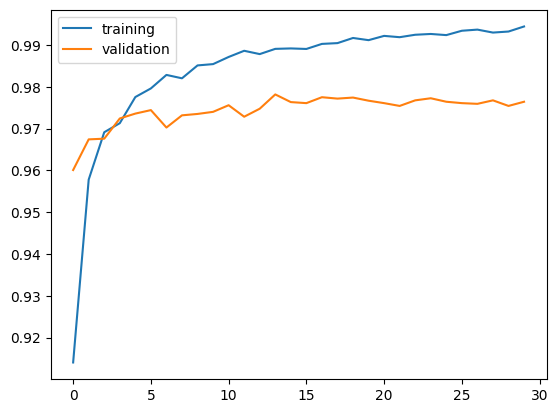

In [ ]:
mnist = tf.keras.datasets.mnist.load_data()
(X_train, y_train), (X_test, y_test) = mnist
X_train, X_test = X_train / 255.0, X_test / 255.0
tf.random.set_seed(42)
model = tf.keras.Sequential()
model.add(tf.keras.layers.Input(shape=[28, 28]))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(100, activation="relu", kernel_initializer="he_normal"))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(100, activation="relu", kernel_initializer="he_normal"))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(10, activation="softmax"))
model.compile(loss="sparse_categorical_crossentropy",
              optimizer="adam",
              metrics=["accuracy"])
history = model.fit(X_train, y_train, epochs=30, validation_split=0.2)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['training', 'validation'], loc = 'upper left')
plt.show()

In [ ]:
model.evaluate(X_test, y_test)

313/313 [==============================] - 1s 2ms/step - loss: 0.1263 - accuracy: 0.9776


[0.12634725868701935, 0.9775999784469604]

# 1.7 MNIST fashion data set

In [ ]:
fashion_mnist = tf.keras.datasets.fashion_mnist.load_data()

In [ ]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]